## Regime-Based Market Strategy Notebook

This notebook builds a weekly S&P 500 decision workflow by:

- Loading long-run price and volume history.
- Engineering return, volatility, and volume features.
- Estimating a Kalman trend and trend-distance z-score.
- Classifying market regimes with a 2-state Gaussian HMM.
- Visualizing trend, regime shifts, and risk-on/risk-off conditions.
- Exporting a JSON weekly playbook with action guidance (`STAY INVESTED`, `DE-RISK`, or `CRITICAL EXIT`).

## Executable Build
This section turns the plan above into a working notebook. Run the cells in order from top to bottom.

### Step 1. Load price history and set strategy parameters
This cell loads the S&P 500 history, defines the working horizon, and sets the default parameters for the Kalman filter and the Hidden Markov Model.

In [58]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from hmmlearn.hmm import GaussianHMM

cwd = Path.cwd().resolve()
project_root = next(path for path in (cwd, *cwd.parents) if (path / "src" / "finance").exists())
src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from finance.data import GSPC_SYMBOL, get_gspc_prices


def format_history_label(period: str) -> str:
    unit_names = {"d": "day", "mo": "month", "y": "year"}
    for unit, unit_name in unit_names.items():
        if period.endswith(unit):
            value = period[: -len(unit)]
            if value.isdigit():
                suffix = "" if value == "1" else "s"
                return f"{value}-{unit_name}{suffix} history"
    return f"{period} history"


history_period = "20y"
history_label = format_history_label(history_period)
vol_window = 21
expanding_scaler_min_periods = 63
n_states = 2
hmm_train_min_periods = 252
hmm_refit_frequency = 21
kalman_process_variance = 0.01
kalman_measurement_variance = 100.0
kalman_burn_in_periods = 252
rolling_exit_window = 252
rolling_exit_min_periods = 63
critical_exit_z = -2.0

gspc_rows = get_gspc_prices(period=history_period, provider="yfinance")
strategy_data = pd.DataFrame(gspc_rows)
strategy_data["date"] = pd.to_datetime(strategy_data["date"], utc=True)
strategy_data = strategy_data.sort_values("date").reset_index(drop=True)

strategy_data[["date", "open", "high", "low", "close", "volume"]].tail()

,date,open,high,low,close,volume
5027,2026-04-13 00:00:00+00:00,6806.470215,6887.000000,6790.020020,6886.240234,4785840000
5028,2026-04-14 00:00:00+00:00,6910.200195,6969.419922,6905.169922,6967.379883,5032380000
5029,2026-04-15 00:00:00+00:00,6978.169922,7026.240234,6967.129883,7022.950195,5278610000
5030,2026-04-16 00:00:00+00:00,7037.779785,7051.229980,7008.520020,7041.279785,5173650000
5031,2026-04-17 00:00:00+00:00,7074.549805,7147.520020,7074.549805,7126.060059,6145300000


### Step 2. Transform the raw history into model inputs
The HMM needs stationary features rather than raw prices, so this cell creates daily returns, rolling volatility, and volume change. Each feature is standardized independently with prior-only expanding statistics, so return, volatility, and volume are each placed on their own comparable z-score scale using only information that would have been available before that date. This prevents the raw unit size of volume from dominating the model.

In [66]:
feature_columns = ["log_return_1d", "realized_vol_21d", "volume_change_1d"]
observation_columns = [f"{column}_z" for column in feature_columns]

strategy_data["observed_close"] = strategy_data["close"].astype(float)
strategy_data["log_close"] = np.log(strategy_data["observed_close"])
strategy_data["log_return_1d"] = strategy_data["log_close"].diff()
strategy_data["realized_vol_21d"] = (
    strategy_data["log_return_1d"].rolling(vol_window).std() * np.sqrt(252)
)
strategy_data["volume_change_1d"] = np.log1p(strategy_data["volume"]).diff()

model_data = strategy_data.dropna(subset=feature_columns).reset_index(drop=True)

def expanding_standardize_by_feature(
    frame: pd.DataFrame,
    columns: list[str],
    min_periods: int,
 ) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    prior_feature_means = (
        frame[columns]
        .expanding(min_periods=min_periods)
        .mean()
        .shift(1)
    )
    prior_feature_stds = (
        frame[columns]
        .expanding(min_periods=min_periods)
        .std(ddof=0)
        .shift(1)
        .replace(0.0, np.nan)
    )
    standardized = frame[columns].sub(prior_feature_means).div(prior_feature_stds)
    return standardized, prior_feature_means, prior_feature_stds

standardized_features, feature_means, feature_stds = expanding_standardize_by_feature(
    model_data,
    feature_columns,
    min_periods=expanding_scaler_min_periods,
 )
valid_rows = standardized_features.notna().all(axis=1)
model_data = model_data.loc[valid_rows].reset_index(drop=True)
feature_means = feature_means.loc[valid_rows].reset_index(drop=True)
feature_stds = feature_stds.loc[valid_rows].reset_index(drop=True)
standardized_features = standardized_features.loc[valid_rows].reset_index(drop=True).astype(float)
model_data[observation_columns] = standardized_features.to_numpy()
hmm_observations = model_data[observation_columns].to_numpy(dtype=float)

if not np.isfinite(hmm_observations).all():
    raise ValueError("Scaled HMM observations must be finite after per-feature standardization.")

scaling_audit = pd.DataFrame(
    {
        "raw_feature_std": model_data[feature_columns].std(ddof=0).round(4),
        "scaled_feature_std": model_data[observation_columns].std(ddof=0).round(4).to_numpy(),
        "scaled_feature_mean": model_data[observation_columns].mean().round(4).to_numpy(),
    },
    index=feature_columns,
 )

scaling_audit

,raw_feature_std,scaled_feature_std,scaled_feature_mean
log_return_1d,0.0124,0.9600,0.0085
realized_vol_21d,0.1136,1.0255,-0.0554
volume_change_1d,0.4821,2.0779,-0.0137


### Step 3. Build the Kalman trend baseline
This cell smooths the price series into a trend estimate and measures how stretched the market is relative to that baseline. The exit logic uses a rolling residual standard deviation, so the threshold adapts to the current market environment rather than using one fixed noise scale for the entire 20-year sample. After the filter runs, the notebook also discards the first year of filtered observations as a burn-in period so the HMM does not learn from the Kalman filter's initial stabilization phase.

In [67]:
def run_kalman_filter(
    series: pd.Series,
    process_variance: float,
    measurement_variance: float,
    initial_state_covariance: float = 1.0,
 ) -> tuple[list[float], list[float]]:
    state_estimate = float(series.iloc[0])
    state_covariance = initial_state_covariance
    filtered_close = []
    kalman_gain = []

    for observed_value in series:
        predicted_estimate = state_estimate
        predicted_covariance = state_covariance + process_variance
        innovation = observed_value - predicted_estimate
        innovation_variance = predicted_covariance + measurement_variance
        gain = predicted_covariance / innovation_variance

        state_estimate = predicted_estimate + gain * innovation
        state_covariance = (1.0 - gain) * predicted_covariance
        filtered_close.append(state_estimate)
        kalman_gain.append(gain)

    return filtered_close, kalman_gain


filtered_close, kalman_gain = run_kalman_filter(
    model_data["observed_close"],
    process_variance=kalman_process_variance,
    measurement_variance=kalman_measurement_variance,
    initial_state_covariance=1.0,
 )

model_data["kalman_close"] = filtered_close
model_data["noise"] = model_data["observed_close"] - model_data["kalman_close"]
model_data["rolling_noise_std"] = (
    model_data["noise"]
    .rolling(rolling_exit_window, min_periods=rolling_exit_min_periods)
    .std(ddof=0)
    .replace(0.0, np.nan)
    .bfill()
    .fillna(1.0)
 )
model_data["distance_to_trend_z"] = model_data["noise"] / model_data["rolling_noise_std"]
model_data["critical_exit_threshold_price"] = (
    model_data["kalman_close"] + critical_exit_z * model_data["rolling_noise_std"]
)

if kalman_burn_in_periods >= len(model_data):
    raise ValueError("kalman_burn_in_periods must be smaller than the number of model observations.")

model_data = model_data.iloc[kalman_burn_in_periods:].reset_index(drop=True)
hmm_observations = hmm_observations[kalman_burn_in_periods:]

model_data[[
    "date",
    "observed_close",
    "kalman_close",
    "noise",
    "rolling_noise_std",
    "distance_to_trend_z",
    "critical_exit_threshold_price",
]].tail()

,date,observed_close,kalman_close,noise,rolling_noise_std,distance_to_trend_z,critical_exit_threshold_price
4691,2026-04-13 00:00:00+00:00,6886.240234,6597.041966,289.198269,238.224653,1.213973,6120.592659
4692,2026-04-14 00:00:00+00:00,6967.379883,6600.726874,366.653009,233.246512,1.571955,6134.233850
4693,2026-04-15 00:00:00+00:00,7022.950195,6604.928049,418.022146,229.375227,1.822438,6146.177594
4694,2026-04-16 00:00:00+00:00,7041.279785,6609.269803,432.009982,225.934969,1.912099,6157.399865
4695,2026-04-17 00:00:00+00:00,7126.060059,6614.411931,511.648128,222.468871,2.299864,6169.474188


### Step 4. Classify the market regime with a walk-forward HMM
This cell refits the HMM on an expanding historical window, then classifies later observations without training on future data. Each refit also applies a canonical state mapping based on the model's volatility emission, so a hidden-state number cannot silently flip from calm to volatile just because the optimizer converged differently.

In [68]:
volatility_feature_name = "realized_vol_21d_z"
volatility_feature_index = observation_columns.index(volatility_feature_name)


def label_states_canonically(model: GaussianHMM, profile: pd.DataFrame) -> dict[int, str]:
    state_order = np.argsort(model.means_[:, volatility_feature_index])
    volatile_state = int(state_order[-1])
    labels: dict[int, str] = {}
    for state in state_order:
        state = int(state)
        if state == volatile_state:
            labels[state] = "volatile-chaos"
        elif profile.loc[state, "mean_return"] >= 0:
            labels[state] = "calm-uptrend"
        else:
            labels[state] = "calm-downtrend"
    return labels


walk_forward_hidden_state = np.full(len(model_data), np.nan)
walk_forward_regime_label = np.full(len(model_data), "", dtype=object)
refit_points: list[str] = []
last_fitted_model: GaussianHMM | None = None
last_state_labels: dict[int, str] = {}

for train_end in range(hmm_train_min_periods, len(model_data), hmm_refit_frequency):
    train_observations = hmm_observations[:train_end]
    hmm_model = GaussianHMM(
        n_components=n_states,
        covariance_type="full",
        n_iter=500,
        random_state=42,
        min_covar=1e-4,
    )
    hmm_model.fit(train_observations)

    train_states = hmm_model.predict(train_observations)
    train_frame = model_data.iloc[:train_end].copy()
    train_frame["hidden_state"] = train_states

    train_profile = train_frame.groupby("hidden_state").agg(
        mean_return=("log_return_1d", "mean"),
        mean_volatility=("realized_vol_21d", "mean"),
        mean_distance_to_trend=("distance_to_trend_z", "mean"),
        count=("hidden_state", "size"),
    )
    state_labels = label_states_canonically(hmm_model, train_profile)

    block_end = min(train_end + hmm_refit_frequency, len(model_data))
    for prediction_end in range(train_end + 1, block_end + 1):
        prefix_states = hmm_model.predict(hmm_observations[:prediction_end])
        predicted_state = int(prefix_states[-1])
        walk_forward_hidden_state[prediction_end - 1] = predicted_state
        walk_forward_regime_label[prediction_end - 1] = state_labels[predicted_state]

    last_fitted_model = hmm_model
    last_state_labels = state_labels
    refit_points.append(model_data.iloc[train_end - 1]["date"].date().isoformat())

predicted_hidden_state = walk_forward_hidden_state[hmm_train_min_periods:]
predicted_regime_label = walk_forward_regime_label[hmm_train_min_periods:]
if np.isnan(predicted_hidden_state).any() or any(label == "" for label in predicted_regime_label):
    raise RuntimeError("Walk-forward HMM did not assign a state to every post-training observation.")

model_data = model_data.iloc[hmm_train_min_periods:].reset_index(drop=True)
model_data["hidden_state"] = predicted_hidden_state.astype(int)
model_data["regime_label"] = predicted_regime_label
hmm_observations = hmm_observations[hmm_train_min_periods:]
hmm_model = last_fitted_model
state_labels = last_state_labels

state_profile = model_data.groupby("regime_label").agg(
    mean_return=("log_return_1d", "mean"),
    mean_volatility=("realized_vol_21d", "mean"),
    mean_distance_to_trend=("distance_to_trend_z", "mean"),
    count=("regime_label", "size"),
)

state_profile = state_profile.assign(
    share_of_sample=lambda frame: frame["count"] / frame["count"].sum(),
).round(4)
volatile_state = max(state_labels, key=lambda state: hmm_model.means_[state, volatility_feature_index])

state_profile

,mean_return,mean_volatility,mean_distance_to_trend,count,share_of_sample
regime_label,,,,,
calm-downtrend,0.0003,0.2330,-0.1296,405,0.0911
calm-uptrend,0.0007,0.1085,2.3190,2335,0.5254
volatile-chaos,0.0000,0.2211,0.6631,1704,0.3834


### Step 5. Visualize price, trend, and regime shifts
The top chart shows price against the Kalman baseline. The bottom chart turns the HMM output into a simple risk-on versus risk-off indicator.

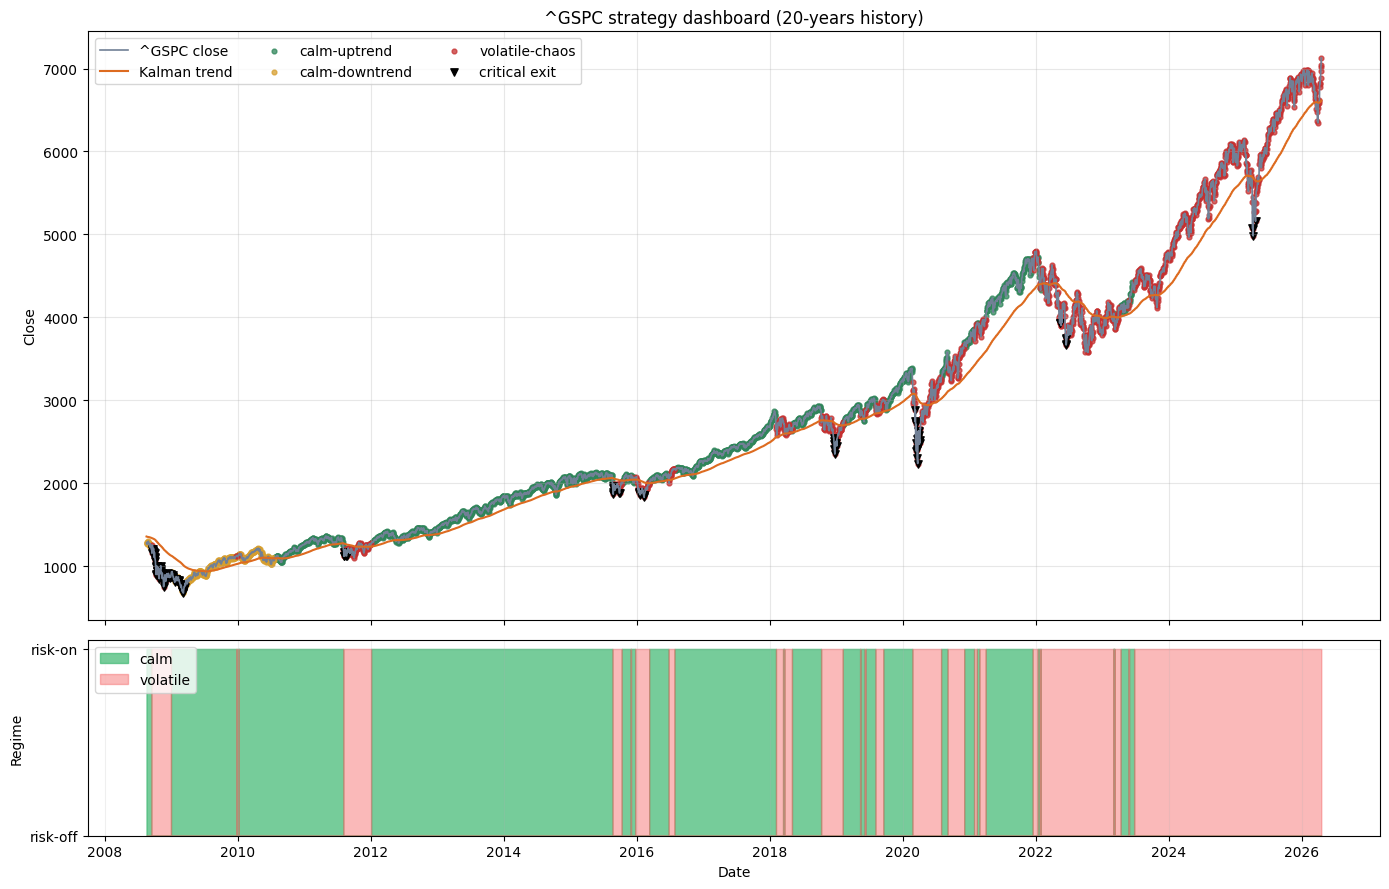

In [62]:
plot_data = model_data.copy()
plot_data["calm_indicator"] = (plot_data["regime_label"] != "volatile-chaos").astype(int)
critical_exit_mask = plot_data["distance_to_trend_z"] <= critical_exit_z

fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 9),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]},
)

axes[0].plot(
    plot_data["date"],
    plot_data["observed_close"],
    color="#718096",
    linewidth=1.2,
    label=f"{GSPC_SYMBOL} close",
)
axes[0].plot(
    plot_data["date"],
    plot_data["kalman_close"],
    color="#dd6b20",
    linewidth=1.5,
    label="Kalman trend",
)

regime_colors = {
    "calm-uptrend": "#2f855a",
    "calm-downtrend": "#d69e2e",
    "volatile-chaos": "#c53030",
}

for regime_label, color in regime_colors.items():
    regime_mask = plot_data["regime_label"] == regime_label
    if regime_mask.any():
        axes[0].scatter(
            plot_data.loc[regime_mask, "date"],
            plot_data.loc[regime_mask, "observed_close"],
            s=12,
            alpha=0.75,
            color=color,
            label=regime_label,
        )

if critical_exit_mask.any():
    axes[0].scatter(
        plot_data.loc[critical_exit_mask, "date"],
        plot_data.loc[critical_exit_mask, "observed_close"],
        marker="v",
        s=28,
        color="black",
        label="critical exit",
    )

axes[0].set_title(f"{GSPC_SYMBOL} strategy dashboard ({history_label})")
axes[0].set_ylabel("Close")
axes[0].grid(alpha=0.3)
axes[0].legend(ncol=3)

axes[1].fill_between(
    plot_data["date"],
    0,
    plot_data["calm_indicator"],
    step="mid",
    color="#48bb78",
    alpha=0.75,
    label="calm",
)
axes[1].fill_between(
    plot_data["date"],
    0,
    (plot_data["regime_label"] == "volatile-chaos").astype(int),
    step="mid",
    color="#f56565",
    alpha=0.45,
    label="volatile",
)
axes[1].set_ylim(0, 1.05)
axes[1].set_yticks([0, 1], labels=["risk-off", "risk-on"])
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Regime")
axes[1].grid(alpha=0.2)
axes[1].legend(loc="upper left")

plt.tight_layout()
plt.show()

### Step 6. Turn the findings into a weekly decision object
This final cell converts the latest model outputs into a JSON summary you can use as your weekly playbook.

In [69]:
latest = model_data.iloc[-1]
prior = model_data.iloc[-2]
last_week = model_data.tail(5).copy()
critical_exit = bool(latest["distance_to_trend_z"] <= critical_exit_z)
state_change_this_week = bool(last_week["regime_label"].nunique() > 1)

if critical_exit:
    action = "CRITICAL EXIT"
    allocation = "Move to cash or gilts"
elif latest["regime_label"] == "volatile-chaos":
    action = "DE-RISK"
    allocation = "Move to cash or gilts"
else:
    action = "STAY INVESTED"
    allocation = "Remain fully invested"

critical_exit_price = float(latest["critical_exit_threshold_price"])

state_findings = []
for regime_label, row in state_profile.iterrows():
    regime_frame = model_data.loc[model_data["regime_label"] == regime_label]
    state_findings.append(
        {
            "regime_label": regime_label,
            "observations": int(row["count"]),
            "share_of_sample": round(float(row["share_of_sample"]), 4),
            "mean_log_return_1d": round(float(row["mean_return"]), 6),
            "mean_realized_vol_21d": round(float(row["mean_volatility"]), 6),
            "mean_distance_to_trend_z": round(float(row["mean_distance_to_trend"]), 6),
            "first_date": regime_frame["date"].min().date().isoformat(),
            "last_date": regime_frame["date"].max().date().isoformat(),
        }
    )

weekly_playbook = {
    "symbol": GSPC_SYMBOL,
    "history_period": history_period,
    "sample_start": model_data["date"].min().date().isoformat(),
    "sample_end": model_data["date"].max().date().isoformat(),
    "latest_observation": {
        "date": latest["date"].date().isoformat(),
        "close": round(float(latest["observed_close"]), 2),
        "kalman_trend": round(float(latest["kalman_close"]), 2),
        "rolling_noise_std": round(float(latest["rolling_noise_std"]), 4),
        "distance_to_trend_z": round(float(latest["distance_to_trend_z"]), 4),
        "critical_exit_threshold_price": round(critical_exit_price, 2),
        "local_hidden_state": int(latest["hidden_state"]),
        "regime_label": latest["regime_label"],
    },
    "decision": {
        "action": action,
        "allocation": allocation,
        "critical_exit_triggered": critical_exit,
        "state_changed_this_week": state_change_this_week,
        "latest_regime_change": bool(latest["regime_label"] != prior["regime_label"]),
    },
    "state_findings": state_findings,
    "latest_transition_matrix": [[round(float(value), 6) for value in row] for row in hmm_model.transmat_],
    "latest_start_probabilities": [round(float(value), 6) for value in hmm_model.startprob_],
    "walk_forward_configuration": {
        "train_min_periods": hmm_train_min_periods,
        "refit_frequency": hmm_refit_frequency,
        "refit_dates": refit_points[-5:],
    },
    "weekly_routine": {
        "run_day": "Friday after the market closes",
        "checks": [
            "Refresh the data and rerun the notebook.",
            "Check whether the regime changed during the week.",
            "Check whether price is more than two rolling standard deviations below the Kalman trend.",
            "Update next Monday's allocation plan.",
        ],
        "last_five_sessions": [
            {
                "date": row.date().isoformat(),
                "regime_label": label,
            }
            for row, label in zip(last_week["date"], last_week["regime_label"], strict=True)
        ],
    },
}

print(json.dumps(weekly_playbook, indent=2))

{
  "symbol": "^GSPC",
  "history_period": "20y",
  "sample_start": "2008-08-18",
  "sample_end": "2026-04-17",
  "latest_observation": {
    "date": "2026-04-17",
    "close": 7126.06,
    "kalman_trend": 6614.41,
    "rolling_noise_std": 222.4689,
    "distance_to_trend_z": 2.2999,
    "critical_exit_threshold_price": 6169.47,
    "local_hidden_state": 0,
    "regime_label": "volatile-chaos"
  },
  "decision": {
    "action": "DE-RISK",
    "allocation": "Move to cash or gilts",
    "critical_exit_triggered": false,
    "state_changed_this_week": false,
    "latest_regime_change": false
  },
  "state_findings": [
    {
      "regime_label": "calm-downtrend",
      "observations": 405,
      "share_of_sample": 0.0911,
      "mean_log_return_1d": 0.0003,
      "mean_realized_vol_21d": 0.233,
      "mean_distance_to_trend_z": -0.1296,
      "first_date": "2008-08-18",
      "last_date": "2010-07-19"
    },
    {
      "regime_label": "calm-uptrend",
      "observations": 2335,
      "sh

### Step 7. Run a simple hypothetical backtest
This cell asks a practical question: what would happen to an initial 1000 GBP if you followed the strategy over the sample? To keep the test honest, the position for each day is based on the signal from the prior trading day, so the notebook does not trade on information from the future. Risk-off periods are treated as cash with a 0% return.

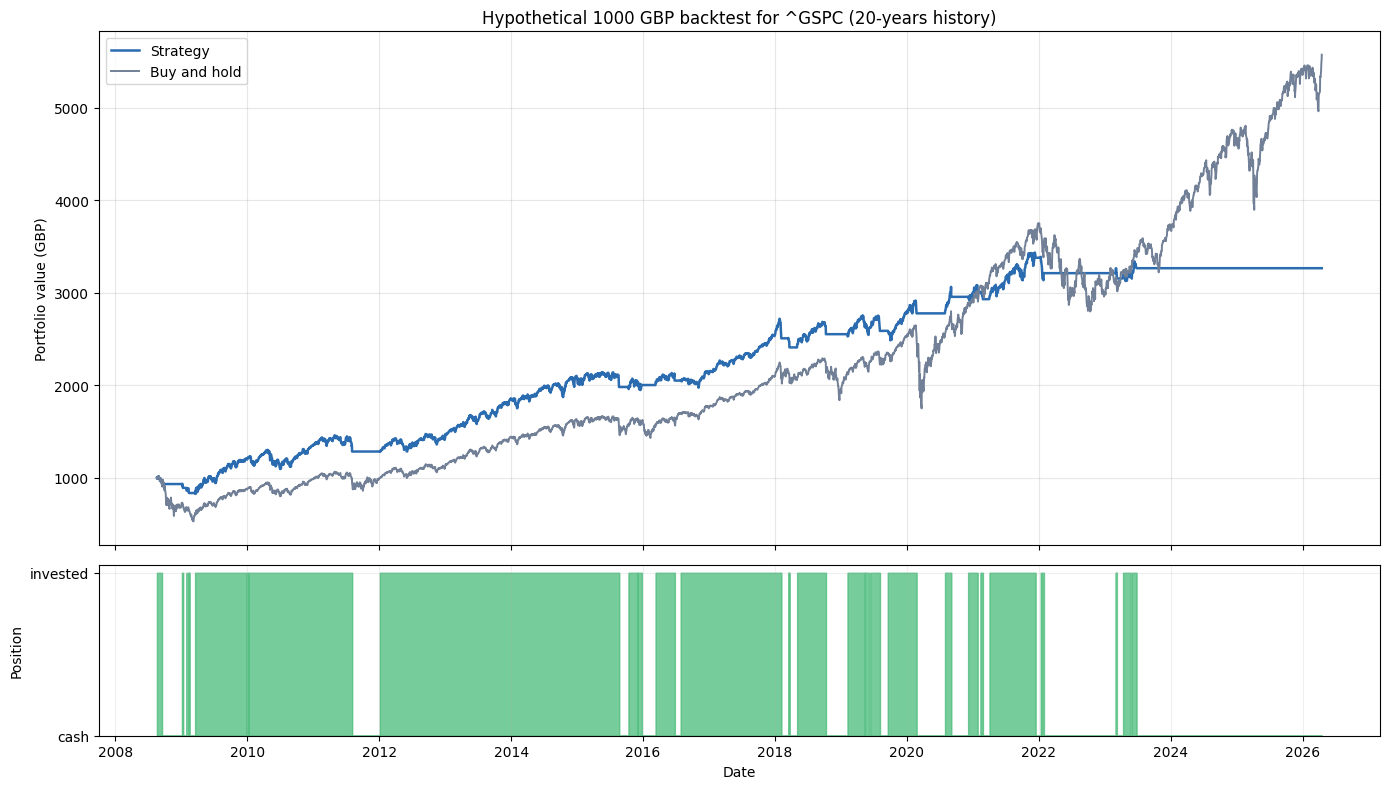

{
  "currency": "GBP",
  "initial_capital": 1000.0,
  "sample_start": "2008-08-18",
  "sample_end": "2026-04-17",
  "assumptions": {
    "execution_timing": "Signal observed after the close, position applied on the next trading day.",
    "risk_off_asset": "Cash",
    "cash_return_assumption": 0.0,
    "transaction_costs_included": false
  },
  "strategy": {
    "final_value_gbp": 3265.47,
    "total_return": 2.2655,
    "cagr": 0.0694,
    "max_drawdown": -0.1885,
    "invested_days": 2701,
    "risk_off_days": 1744
  },
  "buy_and_hold": {
    "final_value_gbp": 5573.33,
    "total_return": 4.5733,
    "cagr": 0.1023,
    "max_drawdown": -0.4799
  }
}


In [70]:
initial_capital_gbp = 1000.0

backtest_data = model_data[[
    "date",
    "observed_close",
    "regime_label",
    "distance_to_trend_z",
]].copy()
backtest_data["asset_return"] = backtest_data["observed_close"].pct_change().fillna(0.0)
backtest_data["risk_off_signal"] = (
    (backtest_data["regime_label"] == "volatile-chaos")
    | (backtest_data["distance_to_trend_z"] <= critical_exit_z)
)

# Trade on the next session to avoid using same-day information.
backtest_data["position"] = np.where(
    backtest_data["risk_off_signal"].shift(1, fill_value=False),
    0.0,
    1.0,
)
backtest_data["strategy_return"] = backtest_data["position"] * backtest_data["asset_return"]
backtest_data["buy_and_hold_return"] = backtest_data["asset_return"]

backtest_data["strategy_value_gbp"] = initial_capital_gbp * (1.0 + backtest_data["strategy_return"]).cumprod()
backtest_data["buy_and_hold_value_gbp"] = initial_capital_gbp * (1.0 + backtest_data["buy_and_hold_return"]).cumprod()
backtest_data["strategy_drawdown"] = (
    backtest_data["strategy_value_gbp"]
    / backtest_data["strategy_value_gbp"].cummax()
    - 1.0
)
backtest_data["buy_and_hold_drawdown"] = (
    backtest_data["buy_and_hold_value_gbp"]
    / backtest_data["buy_and_hold_value_gbp"].cummax()
    - 1.0
)

trading_days = max(len(backtest_data), 1)
strategy_total_return = backtest_data["strategy_value_gbp"].iloc[-1] / initial_capital_gbp - 1.0
buy_and_hold_total_return = backtest_data["buy_and_hold_value_gbp"].iloc[-1] / initial_capital_gbp - 1.0
strategy_cagr = (backtest_data["strategy_value_gbp"].iloc[-1] / initial_capital_gbp) ** (252 / trading_days) - 1.0
buy_and_hold_cagr = (backtest_data["buy_and_hold_value_gbp"].iloc[-1] / initial_capital_gbp) ** (252 / trading_days) - 1.0
strategy_max_drawdown = float(backtest_data["strategy_drawdown"].min())
buy_and_hold_max_drawdown = float(backtest_data["buy_and_hold_drawdown"].min())
risk_off_days = int(backtest_data["risk_off_signal"].sum())
invested_days = int(backtest_data["position"].sum())

backtest_summary = {
    "currency": "GBP",
    "initial_capital": round(initial_capital_gbp, 2),
    "sample_start": backtest_data["date"].min().date().isoformat(),
    "sample_end": backtest_data["date"].max().date().isoformat(),
    "assumptions": {
        "execution_timing": "Signal observed after the close, position applied on the next trading day.",
        "risk_off_asset": "Cash",
        "cash_return_assumption": 0.0,
        "transaction_costs_included": False,
    },
    "strategy": {
        "final_value_gbp": round(float(backtest_data["strategy_value_gbp"].iloc[-1]), 2),
        "total_return": round(float(strategy_total_return), 4),
        "cagr": round(float(strategy_cagr), 4),
        "max_drawdown": round(strategy_max_drawdown, 4),
        "invested_days": invested_days,
        "risk_off_days": risk_off_days,
    },
    "buy_and_hold": {
        "final_value_gbp": round(float(backtest_data["buy_and_hold_value_gbp"].iloc[-1]), 2),
        "total_return": round(float(buy_and_hold_total_return), 4),
        "cagr": round(float(buy_and_hold_cagr), 4),
        "max_drawdown": round(buy_and_hold_max_drawdown, 4),
    },
}

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True, gridspec_kw={"height_ratios": [3, 1]})

axes[0].plot(
    backtest_data["date"],
    backtest_data["strategy_value_gbp"],
    color="#2b6cb0",
    linewidth=1.8,
    label="Strategy",
)
axes[0].plot(
    backtest_data["date"],
    backtest_data["buy_and_hold_value_gbp"],
    color="#718096",
    linewidth=1.4,
    label="Buy and hold",
)
axes[0].set_title(f"Hypothetical 1000 GBP backtest for {GSPC_SYMBOL} ({history_label})")
axes[0].set_ylabel("Portfolio value (GBP)")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].fill_between(
    backtest_data["date"],
    0,
    backtest_data["position"],
    step="mid",
    color="#48bb78",
    alpha=0.75,
)
axes[1].set_ylim(0, 1.05)
axes[1].set_yticks([0, 1], labels=["cash", "invested"])
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Position")
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

print(json.dumps(backtest_summary, indent=2))

In [71]:
cash_mask = backtest_data["position"].eq(0.0)

if cash_mask.any():
    cash_block_id = cash_mask.ne(cash_mask.shift(fill_value=False)).cumsum()
    cash_periods = []

    for _, period in backtest_data.loc[cash_mask].groupby(cash_block_id[cash_mask]):
        start_row = period.iloc[0]
        end_row = period.iloc[-1]
        cash_periods.append(
            {
                "start_date": start_row["date"].date().isoformat(),
                "end_date": end_row["date"].date().isoformat(),
                "calendar_days": int((end_row["date"] - start_row["date"]).days),
                "trading_days": int(len(period)),
                "start_portfolio_value_gbp": round(float(start_row["strategy_value_gbp"]), 2),
                "end_portfolio_value_gbp": round(float(end_row["strategy_value_gbp"]), 2),
                "start_regime": start_row["regime_label"],
                "end_regime": end_row["regime_label"],
                "volatile_chaos_days": int((period["regime_label"] == "volatile-chaos").sum()),
                "critical_exit_days": int((period["distance_to_trend_z"] <= critical_exit_z).sum()),
            }
        )
else:
    cash_periods = []

cash_periods_object = {
    "currency": "GBP",
    "cash_period_count": len(cash_periods),
    "total_cash_trading_days": int(cash_mask.sum()),
    "cash_periods": cash_periods,
}

print(json.dumps(cash_periods_object, indent=2))

{
  "currency": "GBP",
  "cash_period_count": 31,
  "total_cash_trading_days": 1743,
  "cash_periods": [
    {
      "start_date": "2008-09-16",
      "end_date": "2009-01-02",
      "calendar_days": 108,
      "trading_days": 76,
      "start_portfolio_value_gbp": 932.82,
      "end_portfolio_value_gbp": 932.82,
      "start_regime": "volatile-chaos",
      "end_regime": "calm-downtrend",
      "volatile_chaos_days": 74,
      "critical_exit_days": 71
    },
    {
      "start_date": "2009-01-12",
      "end_date": "2009-01-28",
      "calendar_days": 16,
      "trading_days": 12,
      "start_portfolio_value_gbp": 891.32,
      "end_portfolio_value_gbp": 891.32,
      "start_regime": "calm-downtrend",
      "end_regime": "calm-downtrend",
      "volatile_chaos_days": 0,
      "critical_exit_days": 11
    },
    {
      "start_date": "2009-01-30",
      "end_date": "2009-02-05",
      "calendar_days": 6,
      "trading_days": 5,
      "start_portfolio_value_gbp": 861.8,
      "end_por